# Multiple Linear Regression - Toyota Corolla

In [2]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# Load dataset
df = pd.read_csv("ToyotaCorollaMLR.csv")
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [4]:
# Basic information
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1436 non-null   int64
 1   Age_08_04  1436 non-null   int64
 2   KM         1436 non-null   int64
 3   Fuel_Type  1436 non-null   str  
 4   HP         1436 non-null   int64
 5   Automatic  1436 non-null   int64
 6   cc         1436 non-null   int64
 7   Doors      1436 non-null   int64
 8   Cylinders  1436 non-null   int64
 9   Gears      1436 non-null   int64
 10  Weight     1436 non-null   int64
dtypes: int64(10), str(1)
memory usage: 123.5 KB
None
              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000 

In [5]:
#Converting Fuel_Type into numbers
df = pd.get_dummies(df,columns=["Fuel_Type"],drop_first=True)

#Checking updated columns
df.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


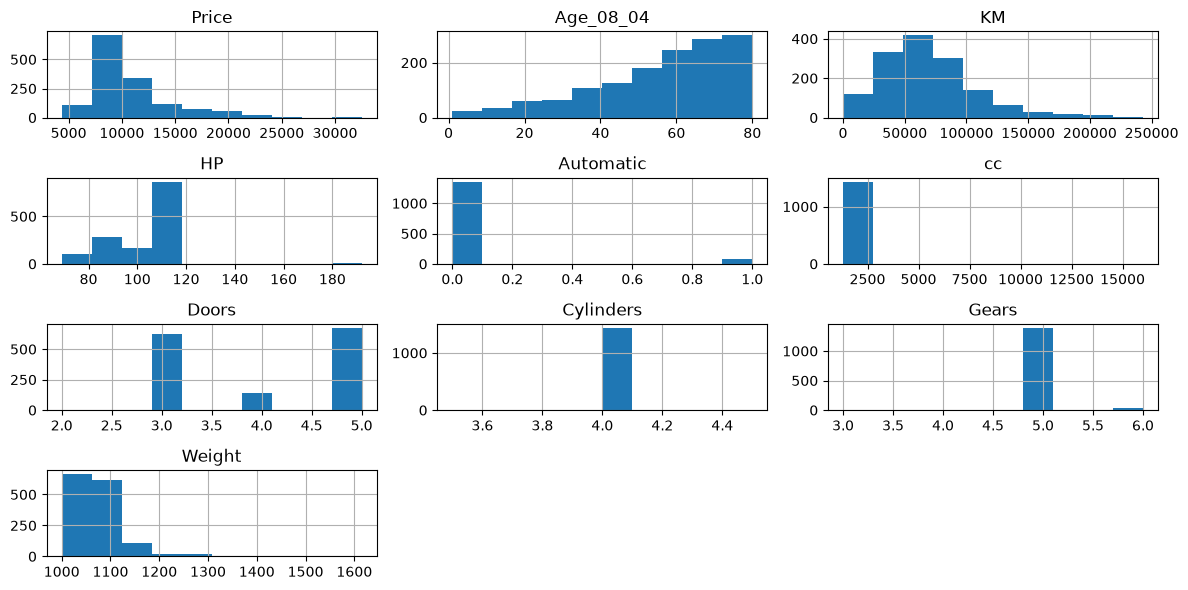

In [6]:
# Histograms
df.hist(figsize=(12,6))
plt.tight_layout()
plt.show()

* Price: Most cars are priced between ₹7,000–₹12,000, with only a few high-priced cars.
* Age_08_04: The dataset contains more older cars (around 60–80 months) than newer ones.
* KM: Most cars have been driven 40,000–90,000 km, while very high-mileage cars are uncommon.
* HP: The majority of cars have around 100–110 horsepower, with very few having extremely high HP.
* Automatic: Most cars have manual transmission (0), and only a small number are automatic.
* CC: Most cars have an engine capacity between 1300–2000 cc, with a few large-engine outliers.
* Doors: 3-door and 5-door cars are the most common, while 2-door and 4-door cars are relatively fewer.
* Cylinders: Almost all cars have 4 cylinders, showing little variation in this feature.
* Gears: Nearly every car has 5 gears, with only a few having 6 gears.
* Weight: Most cars weigh 1000–1100 kg, while heavier cars are comparatively rare.

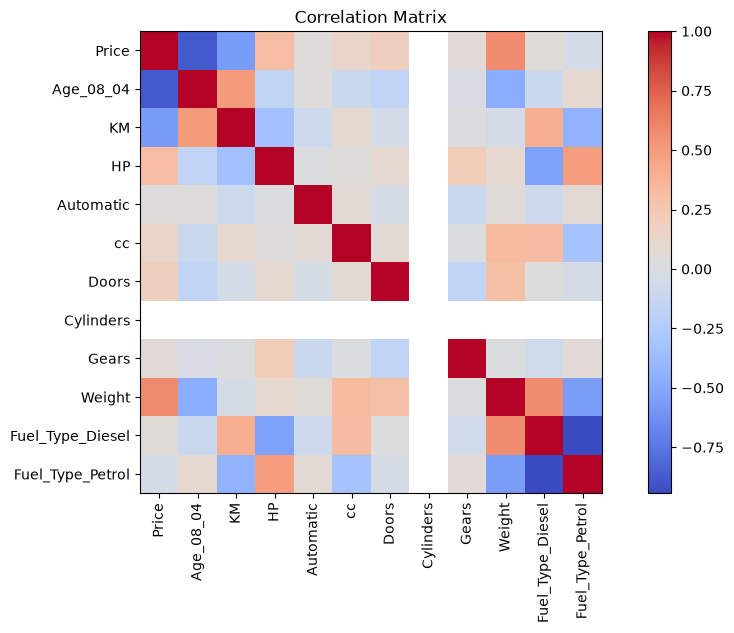

In [16]:
#Correlation matrix
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,6))
plt.imshow(corr,cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)
plt.yticks(range(len(corr.columns)),corr.columns)
plt.title("Correlation Matrix")
plt.show()

* Price has a strong positive correlation with Weight and a strong negative correlation with Age_08_04.
* Older cars (Age_08_04) generally have higher mileage (KM) and lower prices.
* KM shows a moderate positive correlation with Age_08_04, indicating older cars are driven more.
* HP has a moderate positive correlation with Price, suggesting higher horsepower cars tend to cost more.
* Weight is positively correlated with CC and Diesel fuel type, indicating diesel cars are generally heavier.
* CC has a moderate positive correlation with Weight, meaning larger engines are usually found in heavier cars.
* Fuel_Type_Diesel and Fuel_Type_Petrol show a strong negative correlation, as a car cannot belong to both fuel types.
* Automatic, Doors, and Gears have weak correlations with most variables, indicating limited linear relationships.
* Cylinders has almost no variation, so it does not show meaningful correlations with other features.

In [18]:
#Splitting features and target
X = df.drop("Price",axis=1)  #1 for column
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
# Model 1 - All features
model1 = LinearRegression()
model1.fit(X_train,y_train)

pred1 = model1.predict(X_test)

print("Model 1")
print("R2 Score :",r2_score(y_test, pred1))
print("MAE :",mean_absolute_error(y_test,pred1))
print("RMSE :",np.sqrt(mean_squared_error(y_test,pred1)))

Model 1
R2 Score : 0.8348888040611083
MAE : 990.8872739193926
RMSE : 1484.265415329651


In [10]:
# Model 2 - Selected important features
X2 = df[["Age_08_04","KM","HP","Weight"]]
y2 = df["Price"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2,y2,test_size=0.2,random_state=42)

model2 = LinearRegression()
model2.fit(X_train2,y_train2)

pred2 = model2.predict(X_test2)

print("Model 2")
print("R2 Score :",r2_score(y_test2,pred2))
print("MAE :",mean_absolute_error(y_test2,pred2))
print("RMSE :",np.sqrt(mean_squared_error(y_test2,pred2)))

Model 2
R2 Score : 0.8506068681500583
MAE : 1001.2017466053624
RMSE : 1411.85020911323


In [11]:
# Model 3 - Without KM
X3 = df.drop(["Price","KM"], axis=1)
y3 = df["Price"]

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3,y3,test_size=0.2,random_state=42)

model3 = LinearRegression()
model3.fit(X_train3,y_train3)

pred3 = model3.predict(X_test3)

print("Model 3")
print("R2 Score :",r2_score(y_test3,pred3))
print("MAE :",mean_absolute_error(y_test3,pred3))
print("RMSE :",np.sqrt(mean_squared_error(y_test3,pred3)))

Model 3
R2 Score : 0.8078114279853932
MAE : 1070.4865196945518
RMSE : 1601.3530324583244


In [12]:
# Coefficients of Model 1
coef = pd.DataFrame({"Feature": X.columns,"Coefficient": model1.coef_})

print(coef)

             Feature   Coefficient
0          Age_08_04 -1.208305e+02
1                 KM -1.623141e-02
2                 HP  1.403948e+01
3          Automatic  1.488309e+02
4                 cc -3.037219e-02
5              Doors -6.031097e+01
6          Cylinders  1.847411e-12
7              Gears  5.516007e+02
8             Weight  2.588496e+01
9   Fuel_Type_Diesel -6.854876e+01
10  Fuel_Type_Petrol  1.370809e+03


### **Lasso and Ridge Regression**

**Lasso Regression**

Lasso Regression is a regularized version of linear regression that reduces overfitting by adding a penalty to the model. It can also perform feature selection by shrinking some coefficients exactly to zero.

**Ridge Regression**

Ridge Regression is a regularized linear regression technique that reduces overfitting by penalizing large coefficient values. It shrinks the coefficients but retains all features in the model.


In [ ]:
# Lasso Regression
lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print("Lasso R2 :",r2_score(y_test,lasso_pred))

Lasso R2 : 0.8354626403967388


In [14]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
ridge_pred = ridge.predict(X_test)

print("Ridge R2 :",r2_score(y_test,ridge_pred))

Ridge R2 : 0.835135937771233


### Conclusion

The R-squared scores of Multiple Linear Regression, Lasso, and Ridge Regression are very similar, indicating that all three models perform almost equally well. Lasso achieved the highest R-squared score (0.8355), making it the best-performing model, although the improvement over the other models is very small.